In [1]:
# Packages
import os
import time
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from self_dev_tools import module2sdt as m2sdt
from self_dev_tools import module3sdt as m3sdt
from self_dev_tools import module4sdt as m4sdt
from self_dev_tools import module5sdt as m5sdt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

In [2]:
# Reading and organizing

# Filtering files
file_list = os.listdir("./data_folder")
input_file_list = list()
behavior_file_list = list()
mount_file_list = list()
for f in file_list:
    if "Zone" not in f:
        if "behavior" in f:
            behavior_file_list.append(f)
        if "input" in f:
            input_file_list.append(f)
        if "mount" in f:
            mount_file_list.append(f)
        

# Associating the necessary files
vol_file_list = list()

for f in behavior_file_list:
    vol_index = f.strip("vol").strip("behavior.csv")
    for ff in input_file_list:
        if vol_index in ff:
            for fff in mount_file_list:
                if vol_index in fff:
                    vol_file_list.append( (f,ff,fff) )
                

In [3]:
# Opening a file for testing
vol = 5
behavior_str, data_str, mount_str = vol_file_list[vol]
behavior_df = pd.read_csv( os.path.join(os.getcwd() + '/data_folder', behavior_str) )
data_df = pd.read_csv( os.path.join(os.getcwd() + '/data_folder' , data_str) )
mount_df = pd.read_csv( os.path.join(os.getcwd() + '/data_folder' , mount_str) ).drop([31,32]).reset_index(drop=True)

# Converting choices to binary

choices = [0, 1, 2]
for c in choices:
    bin_choice = behavior_df['gk_ch'] == c
    data_df['choice' + str(c)] = bin_choice.astype(int)

data_df = data_df.astype(int)

In [4]:
# Inspecting data_df
data_df

,Fp1 average,Fz average,F3 average,F7 average,FT9 average,FC5 average,FC1 average,C3 average,T7 average,TP9 average,...,FT10 average,FC6 average,FC2 average,F4 average,F8 average,Fp2 average,Cz average,choice0,choice1,choice2
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,1,1,0,1,1,1,0,0,1,0,...,0,0,0,1,0,0,0,0,1,0
2,1,0,1,0,0,0,1,1,0,1,...,1,1,0,1,1,1,1,0,0,1
3,0,1,1,0,0,1,1,1,0,0,...,0,0,1,0,0,1,0,1,0,0
4,0,0,0,1,1,0,1,0,1,0,...,1,0,0,0,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,1,1,1,0,0,0,1,1,1,1,...,1,1,1,0,1,1,0,0,1,0
1496,0,0,0,1,1,1,0,1,1,0,...,1,0,0,0,0,0,1,1,0,0
1497,1,1,1,0,0,0,0,1,0,1,...,0,0,1,1,0,1,0,0,0,1
1498,1,0,1,1,1,1,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0


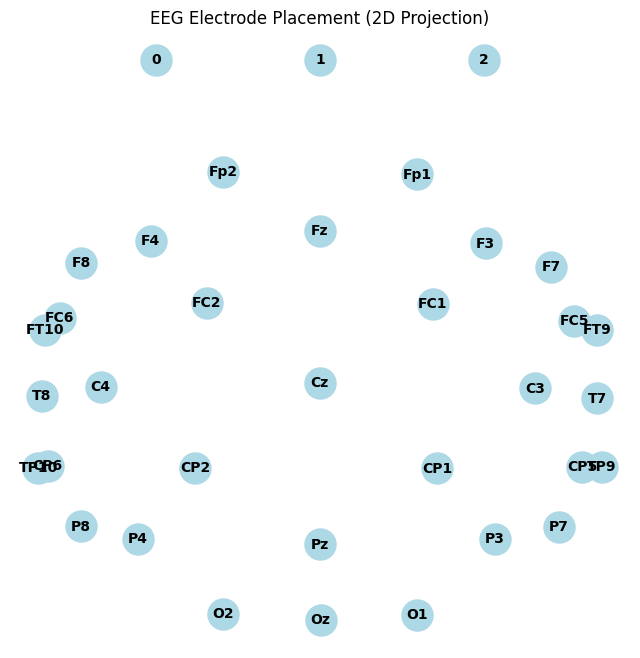

In [5]:
# Assuming you have chan_info in the correct format
channels, splash = m5sdt.get_splash(mount_df)
channels, splash = m5sdt.add_choice_nodes(channels, splash, ['0','1','2'])

# Create a graph
G = nx.Graph()

# Add nodes with positions from splash
for i, name in enumerate(channels):
    G.add_node(name.strip(' average'), pos=(splash[i, 0], splash[i, 1]))

# Extract node positions
pos = nx.get_node_attributes(G, 'pos')

# Plot the graph
plt.figure(figsize=(8, 8))
nx.draw_networkx_nodes(G, pos, node_size=500, node_color='lightblue')
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
nx.draw_networkx_edges(G, pos, alpha=0.5)

plt.title('EEG Electrode Placement (2D Projection)')
plt.axis('off')
plt.show()


In [7]:
start_time = time.time()
# Parameters

trial_start = 300
trial_end = 1000

# Preparing data
sliced_data = m3sdt.load_and_slice_data(data_df, trial_start, trial_end)
train_data, test_data = m3sdt.split_data(sliced_data, test_size=0.3, random_state=42)
neighborhoods, global_summaries = m2sdt.estimate_neighborhoods(train_data, c_cte=0.2, max_ne=7, chunk_size=200, max_candidates=1000)

end_time = time.time()
print(f"Elapsed time {end_time - start_time} sec")

Estimating neighborhoods: 100%|██████████| 3/3 [00:23<00:00,  7.87s/it]

Elapsed time 23.602805376052856 sec


In [ ]:
# NEW FUNCTION: NOT TESTED
def generate_prediction_v3(noi_key, state, global_summaries):
    """
    """
    if noi_key not in global_summaries.keys():
        print('noi key must be in global_summaries')
        return 'no_output', 'no_output'
    
    associate_summary = global_summaries[noi_key]
    check_board = associate_summary['joint_configs']

    # Find all rows where the neighbor states match

    prob_choice = -1
    for i in range(check_board.shape[0]):
        if check_board[i, 1:].tolist() == state and check_board[i,0] == 1:
            prob_choice = associate_summary['probabilities'][i]
    
    if prob_choice == -1:
        p1_num = 0
        for i in range(check_board.shape[0]):
            if check_board[i, 0] == 1:
                p1_num += associate_summary['joint_count'][i]
            p_den += associate_summary['joint_count'][i]

        prob_choice = p1_num / p_den

    return prob_choice

global_summaries['choice2']

#comment: why all choice nodes are 32?

{'node': 32,
 'cdate': [np.int64(3), np.int64(22)],
 'cdnhood_configs': array([[0, 0],
        [0, 1],
        [1, 0],
        [1, 1]]),
 'cdnhood_count': array([136., 111., 107., 136.]),
 'joint_configs': array([[0, 0, 0],
        [0, 0, 1],
        [0, 1, 0],
        [0, 1, 1],
        [1, 0, 0],
        [1, 0, 1],
        [1, 1, 0],
        [1, 1, 1]]),
 'joint_count': array([123.,  86.,  69.,  99.,  13.,  25.,  38.,  37.]),
 'cdconfig_map': array([0., 1., 2., 3., 0., 1., 2., 3.]),
 'probabilities': array([0.90441176, 0.77477477, 0.64485981, 0.72794118, 0.09558824,
        0.22522523, 0.35514019, 0.27205882]),
 'll_hood': np.float64(7.263958668212536e-110),
 'pen_llhood': np.float64(-256.25695959089467)}

In [51]:
predictions, true_labels = m4sdt.predict_testdata(test_data.reset_index(drop=True), neighborhoods, global_summaries)
auc_scores = m4sdt.compute_auc(true_labels, predictions)

# Print the AUC scores
for choice in auc_scores:
    print(f"AUC for {choice}: {auc_scores[choice]:.4f}")

final_labels = m4sdt.predict_final_label(predictions)


AUC for choice0: 0.4440
AUC for choice1: 0.5091
AUC for choice2: 0.4747


In [52]:
# Checking the results
responses = list()
test_data = test_data.reset_index(drop=True)
for r in range( test_data.shape[0]):
    if test_data['choice0'][r] == 1:
        responses.append(0)
    elif test_data['choice1'][r] == 1:
        responses.append(1)
    else:
        responses.append(2)

correct_predictions = 0
for r in range( len(final_labels)):
    if final_labels[r] == responses[r]:
        correct_predictions += 1

correct_predictions = correct_predictions/len(final_labels)
print(f'The number of correct predictions is {correct_predictions}')

The number of correct predictions is 0.4095238095238095


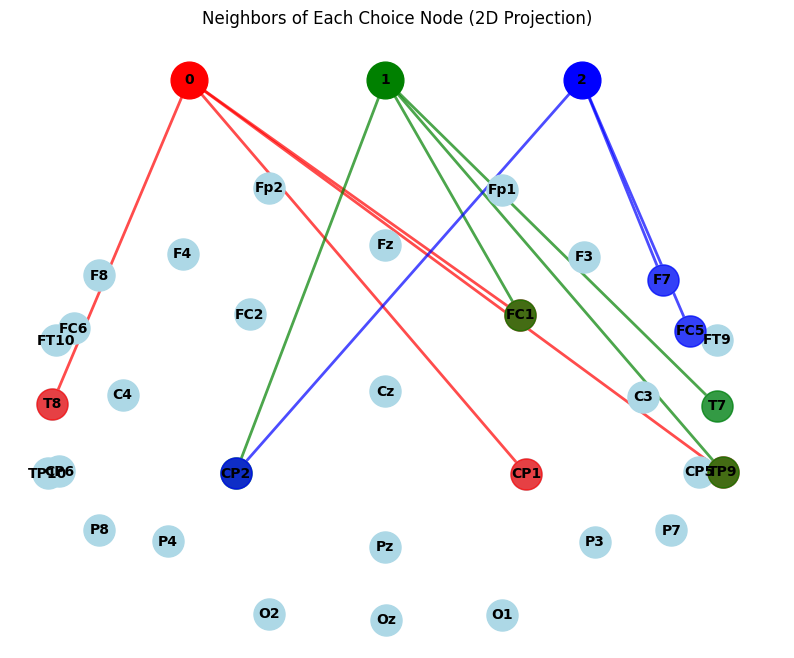

In [53]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Assuming you have chan_info in the correct format
channels, splash = m5sdt.get_splash(mount_df)
channels, splash = m5sdt.add_choice_nodes(channels, splash, ['0', '1', '2'])

# Create a graph
G = nx.Graph()

# Add nodes with positions from splash
for i, name in enumerate(channels):
    G.add_node(name.strip(' average'), pos=(splash[i, 0], splash[i, 1]))

# Extract node positions
pos = nx.get_node_attributes(G, 'pos')

# Plot the base graph (EEG electrodes)
plt.figure(figsize=(10, 8))
nx.draw_networkx_nodes(G, pos, node_size=500, node_color='lightblue')
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

# Define colors for each choice
choice_colors = {
    'choice0': 'red',
    'choice1': 'green',
    'choice2': 'blue'
}

# Loop over each choice and highlight its neighbors
for choice in ['choice0', 'choice1', 'choice2']:
    # Get the neighborhood matrix for the current choice
    neighborhood_matrix = neighborhoods[choice]

    # The choice node is the last node in the matrix
    choice_node_idx = len(channels) - (3 - int(choice[-1]))  # Map choice0/1/2 to the last 3 nodes
    choice_node_name = channels[choice_node_idx].strip(' average')

    # Highlight the choice node
    nx.draw_networkx_nodes(G, pos, nodelist=[choice_node_name], node_size=700, node_color=choice_colors[choice])

    # Get the neighbors of the choice node (last row of the neighborhood matrix)
    neighbors = np.where(neighborhood_matrix[-1, :] == 1)[0]

    # Highlight the edges between the choice node and its neighbors
    for neighbor_idx in neighbors:
        if neighbor_idx < len(channels) - 3:  # Ensure it's not another choice node
            neighbor_name = channels[neighbor_idx].strip(' average')
            nx.draw_networkx_edges(
                G, pos,
                edgelist=[(choice_node_name, neighbor_name)],
                edge_color=choice_colors[choice],
                width=2.0,
                alpha=0.7
            )

    # Highlight the neighbor nodes
    neighbor_names = [channels[neighbor_idx].strip(' average') for neighbor_idx in neighbors if neighbor_idx < len(channels) - 3]
    nx.draw_networkx_nodes(G, pos, nodelist=neighbor_names, node_size=500, node_color=choice_colors[choice], alpha=0.7)

plt.title('Neighbors of Each Choice Node (2D Projection)')
plt.axis('off')
plt.show()


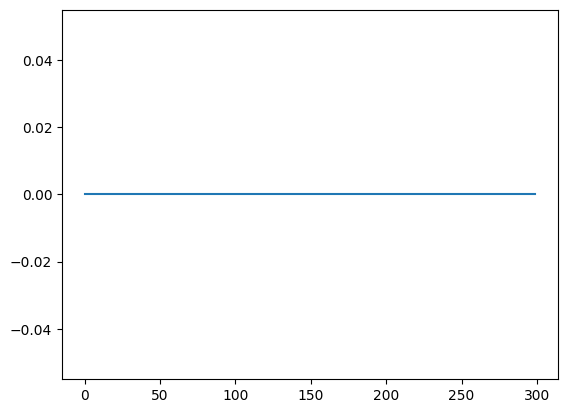

In [16]:
plt.plot([p for p, _ in predictions['choice2']])